## **Problem Statement**

- **This dataset is used to analyze how different house features affect house prices using multiple regression.**

### **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import statsmodels.api as sm
from scipy import stats

from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson

#### **Load Dataset**

In [2]:
df = pd.read_csv("C:/Fawad's Data/Study Data/COMSATS/5th Semester/Econometrics for Business Analytics/kc_house_data.csv")
df.sample(5)

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
3609,809000945,1/6/2015,563000.0,6,1.00,1730,2760,1.5,NO,NONE,...,7 Average,1250,480.0,1918,0.0,98109,47.6342,-122.353,1630,3200
12092,4232900310,10/29/2014,1430000.0,5,4.25,3350,3600,2.0,NO,NONE,...,10 Very Good,2260,1090.0,2014,0.0,98119,47.6351,-122.364,1810,3600
5769,1775800280,2/26/2015,310000.0,5,2.00,2900,11970,2.0,NO,NONE,...,7 Average,2900,0.0,1969,0.0,98072,47.7410,-122.095,1260,12398
625,7812800565,8/14/2014,289500.0,3,1.00,960,6400,1.0,NO,NONE,...,6 Low Average,820,140.0,1944,0.0,98178,47.4960,-122.239,1200,6600
13426,1223059081,3/25/2015,480000.0,3,1.75,1960,43995,1.0,NaN,NONE,...,7 Average,1960,0.0,1970,0.0,98059,47.4915,-122.106,1960,42253


### **Select Relevant Variables**

In [3]:
df = df[['price', 'sqft_living', 'bedrooms', 'bathrooms', 'floors']]
df.head()

,price,sqft_living,bedrooms,bathrooms,floors
0,221900.0,1180,3,1.00,1.0
1,538000.0,2570,3,2.25,2.0
2,180000.0,770,2,1.00,1.0
3,604000.0,1960,4,3.00,1.0
4,510000.0,1680,3,2.00,1.0


### **Research Hypotheses**
To be placed before the regression analysis. For each independent variable, we test the Null Hypothesis ($H_0$) against the Alternative Hypothesis ($H_1$) at a 5% significance level ($\alpha = 0.05$).

---

#### **1. Living Area ($sqft\_living$)**
* **$H_0: \beta_1 = 0$**: Square footage has no effect on house price.  
* **$H_1: \beta_1 \neq 0$**: Square footage has a significant effect on house price.  
* **Theory:** Larger houses provide more utility; price is expected to increase as square footage increases.

#### **2. Bedrooms ($bedrooms$)**
* **$H_0: \beta_2 = 0$**: The number of bedrooms has no effect on house price.  
* **$H_1: \beta_2 \neq 0$**: The number of bedrooms has a significant effect on house price.  
* **Theory:** More bedrooms generally increase value, though too many in a fixed space may reduce individual room size.

#### **3. Bathrooms ($bathrooms$)**
* **$H_0: \beta_3 = 0$**: The number of bathrooms has no effect on house price.  
* **$H_1: \beta_3 \neq 0$**: The number of bathrooms has a significant effect on house price.  
* **Theory:** Additional bathrooms are a convenience feature that typically adds to the market value.

#### **4. Floors (`floors_cat_Low`)**
* **$H_0: \beta_4 = 0$**: Having low floors has no effect on house price compared to higher floors.  
* **$H_1: \beta_4 \neq 0$**: Having low floors significantly affects house price.  
* **Theory:** Houses with fewer floors may have slightly lower value depending on buyer preferences.



### **Perform EDA**

#### **Data Cleaning**

In [4]:
# Missing values
df.isnull().sum()

price          0
sqft_living    0
bedrooms       0
bathrooms      0
floors         0
dtype: int64

In [5]:

# Duplicates
df.duplicated().sum()

np.int64(268)

In [6]:
# remove duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [7]:

# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 21329 entries, 0 to 21596
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        21329 non-null  float64
 1   sqft_living  21329 non-null  int64  
 2   bedrooms     21329 non-null  int64  
 3   bathrooms    21329 non-null  float64
 4   floors       21329 non-null  float64
dtypes: float64(3), int64(2)
memory usage: 999.8 KB


In [8]:
# summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,21329.0,542134.141216,368759.984461,78000.0,324000.00,451000.00,648000.0,7700000.0
sqft_living,21329.0,2086.553988,919.254987,370.0,1430.00,1920.00,2550.0,13540.0
bedrooms,21329.0,3.377280,0.928245,1.0,3.00,3.00,4.0,33.0
bathrooms,21329.0,2.120364,0.768203,0.5,1.75,2.25,2.5,8.0
floors,21329.0,1.494796,0.539160,1.0,1.00,1.50,2.0,3.5


## **Data Visualization**

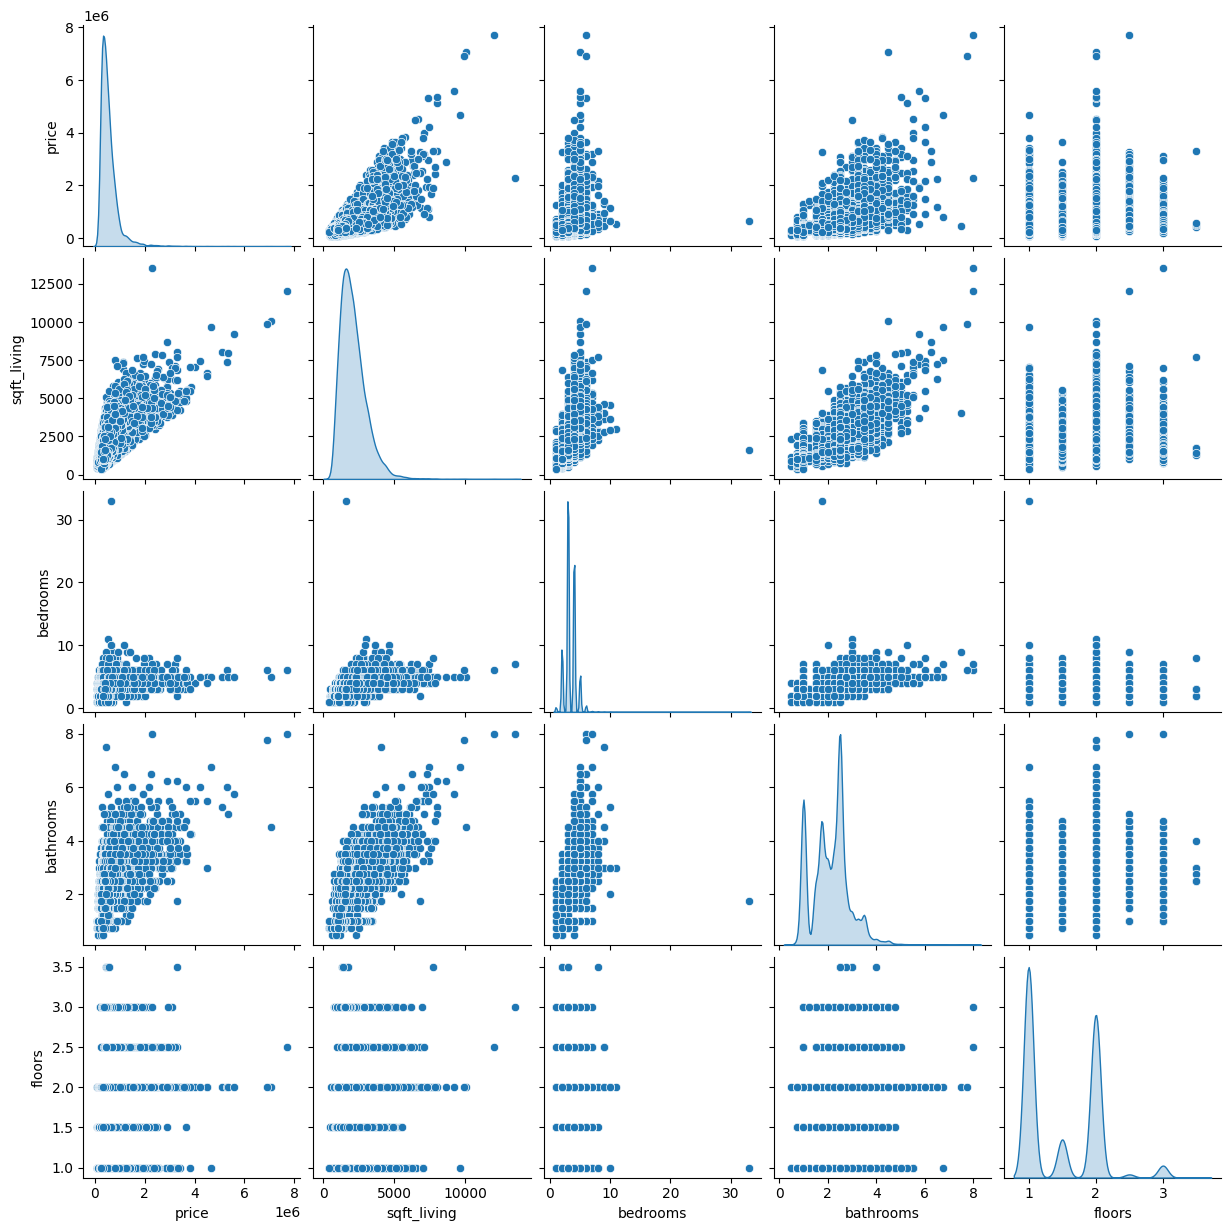

In [9]:
sns.pairplot(df, diag_kind='kde')
plt.show()

In [10]:
fig = px.scatter_3d(df, x='sqft_living', y='bedrooms', z='price', color='floors',
                    title='3D Scatter Plot of House Prices')
fig.show()

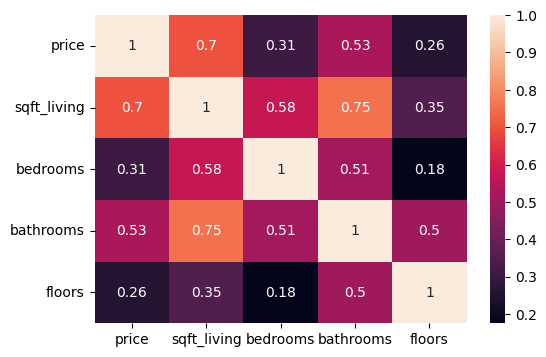

In [11]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(), annot=True)
plt.show()

### **Data Distribution**

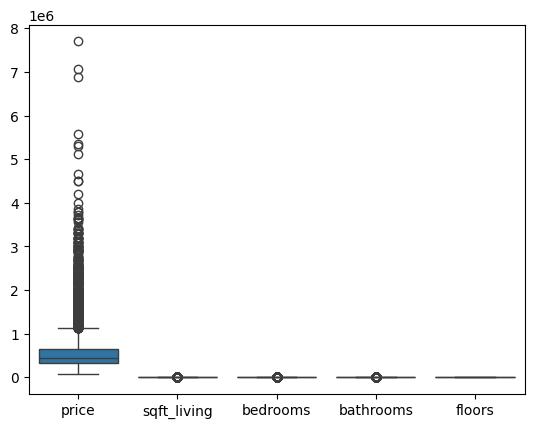

In [12]:
sns.boxplot(data=df)
plt.show()

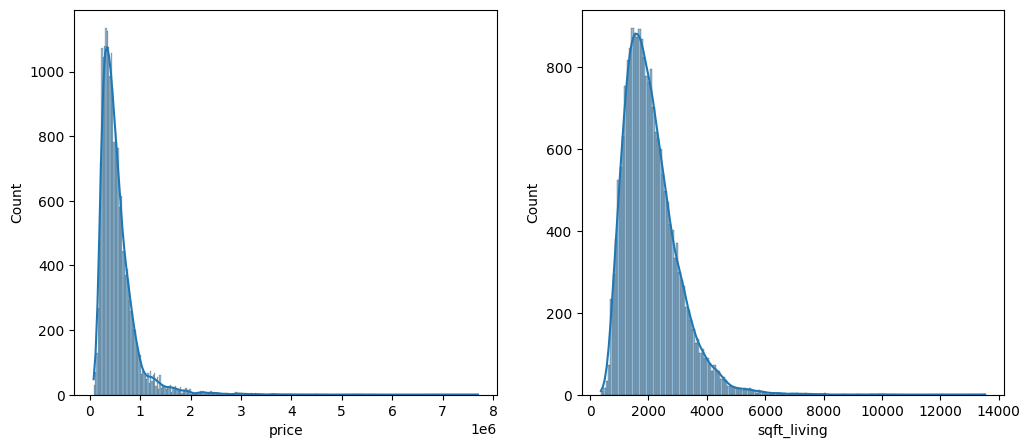

In [13]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True)
plt.subplot(1,2,2)
sns.histplot(df['sqft_living'], kde=True)
plt.show()

- **Right skewed data**

In [14]:

# log transformation
df['price'] = np.log(df['price'])
df['sqft_living'] = np.log(df['sqft_living'])


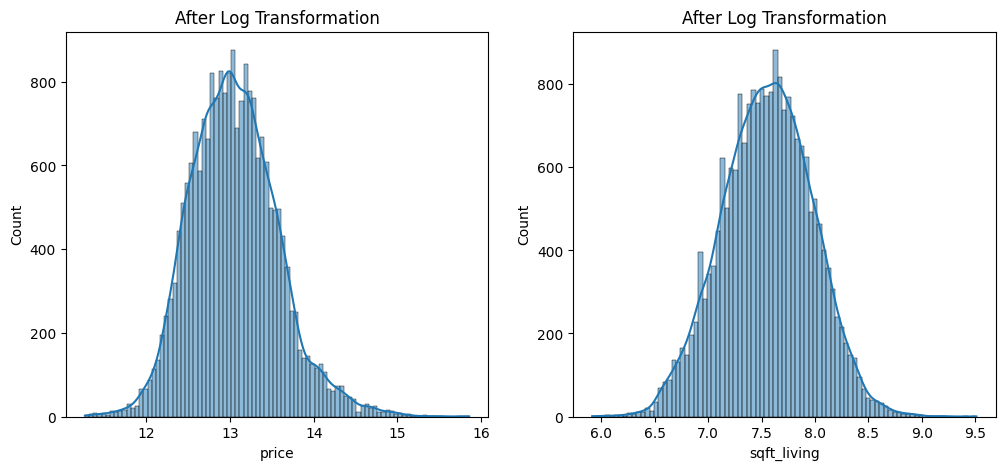

In [15]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(df['price'], kde=True)
plt.title('After Log Transformation')
plt.subplot(1,2,2)
sns.histplot(df['sqft_living'], kde=True)
plt.title('After Log Transformation')
plt.show()

- **Taking the log makes this data much more normal. Will keep that in mind for later.**

In [16]:
# REMOVE OUTLIERS 
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

## **Multiple Linear Regression**

## **Train_test_split**

In [17]:
X = df[['sqft_living', 'bedrooms', 'bathrooms', 'floors']]
y = df['price']

In [18]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25, random_state=0)

In [19]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [20]:
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     3426.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:43:59   Log-Likelihood:                -8364.8
No. Observations:               20133   AIC:                         1.674e+04
Df Residuals:                   20128   BIC:                         1.678e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           7.0107      0.069    101.841      

- Not multicollinearity issue (VIF was fine) so  it's economic interpretation issue
- Bedrooms show a negative coefficient due to overlapping information with house size.

In [21]:
print("Intercept:",lr.intercept_)
print("Coefficients:",lr.coef_)
y_pred = lr.predict(X_test)
y_pred

Intercept: 6.987994439651344
Coefficients: [ 0.82089012 -0.08061095  0.01514314  0.05817429]


array([12.35604625, 12.90917279, 12.92567053, ..., 12.4649834 ,
       13.23294985, 13.21437308], shape=(5034,))

## **Multicollinearity (VIF)**

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif

,Variable,VIF
0,const,709.687633
1,sqft_living,2.629043
2,bedrooms,1.622207
3,bathrooms,2.544944
4,floors,1.359508


- no multicollinearity problem.

## **Normality Check (QQ Plot)**

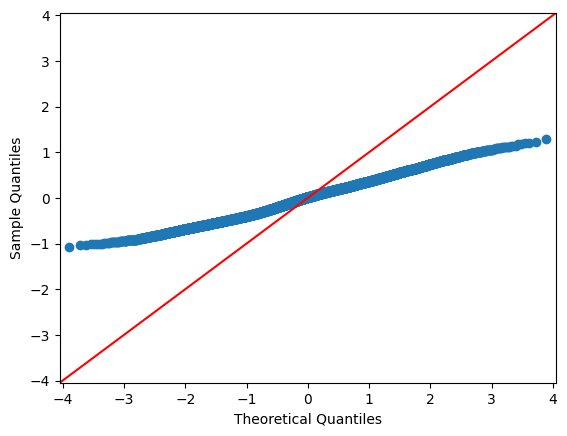

In [23]:
residuals = model.resid

sm.qqplot(residuals, line='45')
plt.show()

In [24]:
stats.jarque_bera(model.resid)

SignificanceResult(statistic=np.float64(124.74177769203179), pvalue=np.float64(8.17837730788887e-28))

- p-value  is small so slight non normality (acceptable)

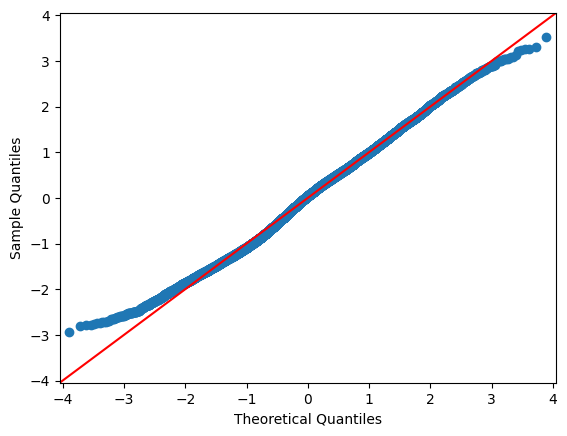

In [25]:
residuals = model.resid

# Standardize residuals
residuals = (residuals - residuals.mean()) / residuals.std()

sm.qqplot(residuals, line='45')
plt.show()

### **Heteroscedasticity Test**

In [26]:
test = het_breuschpagan(residuals, X)
print("p-value:", test[1])

p-value: 9.113236707874817e-31


In [ ]:
X = sm.add_constant(X)

model_reduced = sm.OLS(y, X).fit(cov_type='HC3')
print(model_reduced.summary())                                                                          

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     3378.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:44:01   Log-Likelihood:                -8364.8
No. Observations:               20133   AIC:                         1.674e+04
Df Residuals:                   20128   BIC:                         1.678e+04
Df Model:                           4                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           7.0107      0.068    103.034      

- **Bathrooms shows minimal, insignificant effect, so we remove it to simplify the model and focus on key predictors**

### **Reduced Model (REMOVE bathrooms)**

In [28]:
X = df[['sqft_living', 'bedrooms', 'floors']]
y = df['price']

In [ ]:

X = sm.add_constant(X)

model_reduced = sm.OLS(y, X).fit(cov_type='HC3')
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     4493.
Date:                Fri, 03 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:44:01   Log-Likelihood:                -8366.3
No. Observations:               20133   AIC:                         1.674e+04
Df Residuals:                   20129   BIC:                         1.677e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           6.9428      0.057    120.815      

In [30]:
dw = durbin_watson(residuals)
print("Durbin Watson:", dw)

Durbin Watson: 1.9732462214570767


- **Close to 2 → No autocorrelation**

### **Dummy Variable Creation**

In [ ]:
# Create category column
df['floors_cat'] = df['floors'].apply(lambda x: 'Low' if x <= 1 else 'High')
# Create dummy variable 
df = pd.get_dummies(df, columns=['floors_cat'], drop_first=True, dtype=int)
print(df.columns)

Index(['price', 'sqft_living', 'bedrooms', 'bathrooms', 'floors',
       'floors_cat_Low'],
      dtype='object')


### **Regression with dummy variables**

In [ ]:
X = df[['sqft_living', 'bedrooms', 'floors_cat_Low']]
y = df['price']
X = sm.add_constant(X)

model = sm.OLS(y, X).fit(cov_type='HC3')
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.405
Model:                            OLS   Adj. R-squared:                  0.405
Method:                 Least Squares   F-statistic:                     4520.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        05:12:59   Log-Likelihood:                -8360.6
No. Observations:               20133   AIC:                         1.673e+04
Df Residuals:                   20129   BIC:                         1.676e+04
Df Model:                           3                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.0890      0.062    114.

* Removing **bathrooms** simplified the model without reducing explanatory power.
- **Intercept (`const`) = 7.0890**: Baseline value when all predictors are zero; highly significant.  
- **`sqft_living` = 0.8273**: Strong positive effect; slightly higher than before; highly significant.  
- **`bedrooms` = -0.0801**: Small negative effect; slightly more negative than before; significant.  
- **`floors_cat_Low` = -0.0695**: Houses with low floors have a small but significant decrease in the target variable.